# AIFM Hedge Fund — Risk Notebook

AIFM Risk limits are defined in the fund's offering document and monitored against
internal thresholds. No regulatory VaR limit applies (unlike UCITS).

Key regulatory obligations under AIFMD:
- **Leverage**: gross and commitment method (Annex IV)
- **Stress testing**: market, liquidity, and counterparty scenarios (Annex VI)
- **Liquidity risk**: portfolio liquidity profile and redemption stress
- **Annex IV reporting**: quarterly to CSSF. AIFMD II (Directive 2024/927/EU)
  expanded requirements, adding granular data on liquidity management tools,
  loan origination, and delegation arrangements.




In this notebook

Risk analysis for the AIFM Hedge Fund under AIFMD.
* Strategy: Long/short equity, bonds, FX, options.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.database import get_engine, query_positions, query_nav_history
from src.enrichment import enrich_positions, get_risk_ready_df
from src.mock_bloomberg import MockBloomberg as Bloomberg
from src.risk_utils import (
    var_historical, var_parametric, var_scale, var_montecarlo,
    es_historical, es_parametric, es_scale,
    kupiec_test, christoffersen_test,
    exception_report, full_backtest_report,
    stress_equity, stress_rates, stress_credit,
    stress_fx, stress_combined, stress_historical,
    days_to_liquidate, liquidity_buckets, redemption_stress,
)

FUND_ID    = 'AIFM_HedgeFund'
TODAY      = '2026-05-13'
ENGINE     = get_engine()
BBG        = Bloomberg()

ACCENT     = '#2563EB'
ACCENT2    = '#DC2626'
ACCENT3    = '#16A34A'

CONFIDENCE = 0.99
HORIZON    = 20

ImportError: cannot import name 'var_montecarlo' from 'src.risk_utils' (/Users/mrspatbile/Documents/coding/manco-risk-mngmt/src/risk_utils.py)

## 1. Load and Validate Positions

Positions are queried from SQLite, which is loaded daily from the fund administrator
Excel export. The flow is:

Fund admin Excel → load_positions() → SQLite → query_positions() → notebook

`get_risk_ready_df` runs the enrichment pipeline on the raw positions:
- liquid instruments (equities, bonds, ETFs): sensitivities fetched from Bloomberg
  (beta, modified duration, convexity, spread duration)
- illiquid instruments (loans, direct properties): fund admin data already embedded
  in the position file (rating, maturity, LTV, rental yield) used directly,
  no Bloomberg ticker available or needed

The output is a single enriched DataFrame per fund per date, ready for VaR,
stress testing, and liquidity analysis.

In [5]:
positions = query_positions(ENGINE, FUND_ID, TODAY)
risk_df   = get_risk_ready_df(ENGINE, FUND_ID, TODAY)
NAV       = risk_df['market_value_eur'].sum()

print(f"Fund           : {FUND_ID}")
print(f"Valuation date : {TODAY}")
print(f"Positions      : {len(positions)}")
print(f"NAV (EUR)      : {NAV:,.0f}")
print(f"Asset classes  : {sorted(positions['asset_class'].unique())}")
print(f"Long exposure  : {risk_df[risk_df['market_value_eur'] > 0]['market_value_eur'].sum():,.0f}")
print(f"Short exposure : {risk_df[risk_df['market_value_eur'] < 0]['market_value_eur'].sum():,.0f}")

Fund           : AIFM_HedgeFund
Valuation date : 2026-05-13
Positions      : 14
NAV (EUR)      : 94,623,895
Asset classes  : ['Bond', 'Cash', 'Derivative', 'Equity', 'FX']
Long exposure  : 105,310,570
Short exposure : -10,686,675


In [6]:
# Asset class breakdown
breakdown = risk_df.groupby('asset_class').agg(
    market_value_eur=('market_value_eur', 'sum'),
    n_positions=('isin', 'count'),
).sort_values('market_value_eur', ascending=False)

breakdown['weight_pct'] = breakdown['market_value_eur'] / NAV * 100

print(f"{'Asset Class':<20} {'MV (EUR)':>15} {'Weight':>8} {'# Pos':>6}")
print('-' * 52)
for ac, row in breakdown.iterrows():
    print(f"{ac:<20} {row['market_value_eur']:>15,.0f} {row['weight_pct']:>7.1f}% {row['n_positions']:>6}")
print('-' * 52)
print(f"{'NAV':<20} {NAV:>15,.0f} {'100.0%':>8}")

Asset Class                 MV (EUR)   Weight  # Pos
----------------------------------------------------
Equity                    60,120,885    63.5%    7.0
FX                        15,922,100    16.8%    2.0
Cash                      10,000,000    10.6%    1.0
Bond                       8,983,190     9.5%    3.0
Derivative                  -402,280    -0.4%    1.0
----------------------------------------------------
NAV                       94,623,895   100.0%


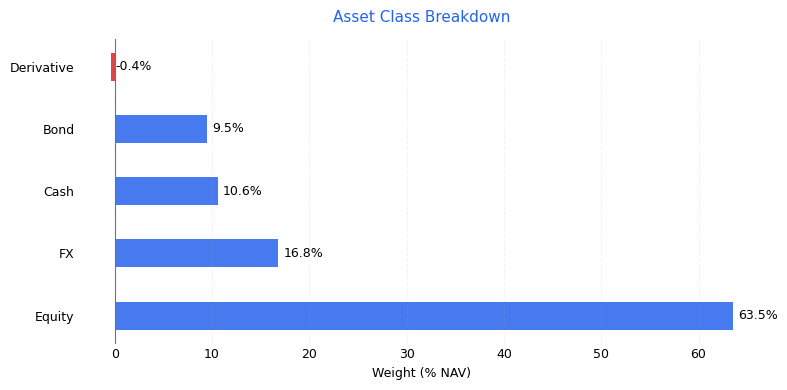

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [ACCENT2 if v < 0 else ACCENT for v in breakdown['weight_pct']]
bars = ax.barh(breakdown.index, breakdown['weight_pct'],
               color=colors, height=0.45, alpha=0.85)
ax.axvline(0, color='#6b7280', lw=0.8)
ax.set_xlabel('Weight (% NAV)', fontsize=9)
ax.set_title('Asset Class Breakdown', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='x', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
for bar, val in zip(bars, breakdown['weight_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. VaR and Expected Shortfall

VaR and ES are computed using historical simulation on daily NAV returns.
Under AIFMD there is no regulatory VaR limit, but VaR is monitored against
internal limits defined in the RMP and reported in Annex IV.

- Confidence: 99%
- Horizon: 1-day and 20-day (square root of time scaling)
- Method: historical simulation, 250-day rolling window

In [8]:
nav_history = query_nav_history(ENGINE, FUND_ID)
nav_history['date'] = pd.to_datetime(nav_history['date'])
pnl = nav_history['pnl_pct'].dropna().values

var_1d  = var_historical(pnl[-250:], confidence=CONFIDENCE)
var_20d = var_scale(var_1d, horizon=HORIZON)
es_1d   = es_historical(pnl[-250:], confidence=CONFIDENCE)
es_20d  = es_scale(es_1d, horizon=HORIZON)

print(f"{'Metric':<25} {'1-day':>10} {'20-day':>10}")
print('-' * 46)
print(f"{'VaR 99% (% NAV)':<25} {var_1d*100:>9.2f}% {var_20d*100:>9.2f}%")
print(f"{'ES 99% (% NAV)':<25} {es_1d*100:>9.2f}% {es_20d*100:>9.2f}%")
print(f"{'VaR 99% (EUR)':<25} {var_1d*NAV:>10,.0f} {var_20d*NAV:>10,.0f}")
print(f"{'ES 99% (EUR)':<25} {es_1d*NAV:>10,.0f} {es_20d*NAV:>10,.0f}")

Metric                         1-day     20-day
----------------------------------------------
VaR 99% (% NAV)                1.09%      4.89%
ES 99% (% NAV)                 1.26%      5.62%
VaR 99% (EUR)              1,034,568  4,626,731
ES 99% (EUR)               1,189,373  5,319,037
